# Import and methods

In [1]:
%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt

from collections import OrderedDict
from pycolleff.longitudinal_equilibrium import ImpedanceSource, LongitudinalEquilibrium
import pycolleff.rings.sirius as sirius
import pycolleff.impedances as imp

# mplt.style.use('science')
plt.rcParams.update({
    'font.size': 18, 'axes.grid': True,
    'grid.linestyle': '--', 'grid.alpha': 0.5})

plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.right'] = False
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.top'] = False

import matplotlib.cm as cm
import matplotlib.colors as mcolors

from scipy.constants import speed_of_light as c

In [2]:
def create_equilibrium(ring, impedances, feedback=False):
    fill = np.ones(ring.harm_num) / ring.harm_num
    equi = LongitudinalEquilibrium(ring=ring, impedance_sources=impedances, fillpattern=fill)
    equi.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb / 2
    equi.feedback_on = feedback
    equi.identical_bunches = True
    return equi

def set_harmonic_voltage(goal_voltage, equi, nr_equi_iters=50):
    hcav = equi.impedance_sources[-1]
    for _ in range(nr_equi_iters):
        angle = equi.calc_detune_for_fixed_harmonic_voltage(
            goal_voltage, Rs=hcav.shunt_impedance, harm_rf=hcav.harm_rf)
        equi.impedance_sources[-1].detune_angle = angle
        equi.calc_longitudinal_equilibrium(niter=10000, beta=0.1, tol=1e-8, m=3, print_flag=False)


In [3]:
def scan_hc_voltage(voltages, equi, cbmode, mmax, nr_equi_iters=20):
    ad_rates, cf_rates, mc_rates = [], [], []
    ich_freq, min_freq, max_freq = [], [], []

    print("HC voltage (kV)  HC detune (kHz)")

    hcav = equi.impedance_sources[-1]
    for voltage in voltages:
        for _ in range(nr_equi_iters):
            detune_angle = equi.calc_detune_for_fixed_harmonic_voltage(
                peak_harm_volt=voltage, Rs=hcav.shunt_impedance, harm_rf=hcav.harm_rf)
            equi.impedance_sources[-1].detune_angle = detune_angle
            equi.calc_longitudinal_equilibrium(niter=10000, beta=0.1, tol=1e-8, m=3, print_flag=False)

        print(f"{voltage / 1e3:15.2f} {equi.impedance_sources[-1].detune_freq / 1e3:15.2f}")

        equi.calc_equilibrium_info(nrpts=51)
        _ = equi.calc_canonical_transformation()

        zij = equi.equilibrium_info["canonical_zj"]
        min_freq.append(equi.equilibrium_info["sync_freq"].min())
        max_freq.append(equi.equilibrium_info["sync_freq"].max())

        ms = np.arange(1, mmax + 1)
        ps = np.array([-3, 3])
        w0 = equi.ring.rev_ang_freq
        h = equi.ring.harm_num
        hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)

        z0, sigmaz = equi.calc_moments(equi.zgrid, equi.distributions)
        sigmaz = sigmaz[0]
        sync_freq = equi.ring.espread * equi.ring.mom_comp * c / (sigmaz * 2 * np.pi)

        x0 = [2 * np.pi * sync_freq, equi.ring.dampte]
        coherent_freq, growth_rate = equi.solve_lebedev(x0, hmps, ms, ps, cbmode, method='lm', reduced=True)
        ad_rates.append(coherent_freq + 1j * growth_rate)

        ms = np.sort(np.r_[-np.arange(1, mmax + 1), np.arange(1, mmax + 1)])
        hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)
        eigvals, _ = equi.solve_lebedev_constant_frequency(hmps, ms, ps, cbmode, effsyncfreq='bunchlength')
        cf_rates.append(eigvals)
        ich_freq.append(sync_freq)

        equi.ring.sync_tune = sync_freq / equi.ring.rev_freq
        equi.ring.bunlen = sigmaz

        wrf = equi.ring.rf_ang_freq
        eigenfreq, *_ = equi.calc_mode_coupling(
            w=[-10 * wrf, +10 * wrf],
            cbmode=cbmode,
            max_azi=mmax,
            max_rad=1,
            use_fokker=False,
            delete_m0=True,
            delete_m0k0=True,
            reduced=True,
        )
        mc_rates.append(eigenfreq)

    return (
        np.array(ad_rates),
        np.array(cf_rates),
        np.array(mc_rates),
        np.array(ich_freq),
        np.array(min_freq),
        np.array(max_freq),
    )


In [4]:
def plot_scan_hc_voltage(voltages, fp_voltage, ad_rates, cf_rates, mc_rates, ich_freq,
                         xticks=None, yticks=None, xlim=None, ylim=None, filename=None):
    fig = plt.figure(figsize=(8, 6))
    scale = 1
    plt.plot(voltages / 1e3, np.abs(ad_rates.real) * scale, 'o', ms=9, color='tab:gray', label=r'Re($\Omega$) Lebedev', alpha=0.5)
    plt.plot(voltages / 1e3, np.abs(cf_rates.real) / 2 / np.pi * scale, 'x', color='g', label=r'Re($\Omega$) Effective ${\omega_s}(\sigma_z)$')
    plt.plot(voltages / 1e3, np.abs(mc_rates.real) / 2 / np.pi * scale, '.', color='tab:orange', label=r'Re($\Omega$) Gaussian LMCI')
    plt.plot(voltages / 1e3, ich_freq * scale, color="k", label=r"Incoherent $m{\omega_s}(\sigma_z)$")
    plt.plot(voltages / 1e3, 2 * np.array(ich_freq) * scale, color="k")

    plt.axvline(fp_voltage / 1e3, ls='--', color='tab:gray', lw=2)

    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.grid(True, ls='--', alpha=0.25)
    plt.xlabel("harmonic voltage (kV)")
    plt.ylabel("frequency (Hz)")

    limit = 1 / equi.ring.dampte
    grows = np.abs(ad_rates.imag)
    first_true = next((i for i, g in enumerate(grows) if g > limit), None)

    if first_true is not None:
        instability_limit = voltages[first_true] / 1e3
        print("HC voltage threshold (kV)")
        print(instability_limit)
        plt.axvline(instability_limit, color='tab:red', linestyle=":", alpha=0.5, lw=2)
        plt.axvspan(instability_limit, voltages.max() / 1e3, color='tab:red', alpha=0.1,
                    label=r"Unstable Im($\Omega$) $> 1/\tau_\delta$")

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize="x-small", ncol=2, loc='upper right')
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename)
    plt.show()


def plot_scan_hc_voltage_growth(voltages, fp_voltage, ad_rates, cf_rates, mc_rates, ich_freq,
                                xticks=None, yticks=None, xlim=None, ylim=None, filename=None):
    fig = plt.figure(figsize=(8, 6))
    plt.plot(voltages / 1e3, ad_rates.imag, 'o', ms=9, color='tab:gray', label=r'Im($\Omega$) Lebedev', alpha=0.5)
    plt.plot(voltages / 1e3, cf_rates.imag, 'x', color='g', label=r'Im($\Omega$) Effective')
    plt.plot(voltages / 1e3, mc_rates.imag, '.', color='tab:orange', label=r'Im($\Omega$) Gaussian LMCI')

    plt.axvline(fp_voltage / 1e3, ls='--', color='tab:gray', lw=2)

    if xticks is not None:
        plt.xticks(xticks)
    if yticks is not None:
        plt.yticks(yticks)
    if xlim is not None:
        plt.xlim(xlim)
    if ylim is not None:
        plt.ylim(ylim)

    plt.grid(True, ls='--', alpha=0.25)
    plt.xlabel("harmonic voltage (kV)")
    plt.ylabel("growth rate (1/s)")

    limit = 1 / equi.ring.dampte
    grows = np.abs(ad_rates.imag)
    first_true = next((i for i, g in enumerate(grows) if g > limit), None)

    if first_true is not None:
        instability_limit = voltages[first_true] / 1e3
        print("HC voltage threshold (kV)")
        print(instability_limit)
        plt.axvline(instability_limit, color='tab:red', linestyle=":", alpha=0.5, lw=2)
        plt.axvspan(instability_limit, voltages.max() / 1e3, color='tab:red', alpha=0.1,
                    label=r"Unstable Im($\Omega$) $> 1/\tau_\delta$")

    handles, labels = plt.gca().get_legend_handles_labels()
    by_label = OrderedDict(zip(labels, handles))
    plt.legend(by_label.values(), by_label.keys(), fontsize="x-small", ncol=2, loc='upper right')
    plt.tight_layout()
    if filename is not None:
        plt.savefig(filename)
    plt.show()


In [5]:
def scan_current_keep_fp(currents, ring, impedances, cbmode, mmax, nr_equi_iters=20, method='lebedev'):
    rates, ich_freq = [], []
    threshold_current = None

    print("HC voltage (kV)  HC detune (kHz)")

    for current in currents:
        print(f"Current: {current * 1e3:.2f} mA")
        ring.total_current = current
        equi = create_equilibrium(ring, impedances)
        hcav = equi.impedance_sources[-1]
        k = equi.calc_harmonic_voltage_for_flat_potential(harm_rf=hcav.harm_rf)
        peak_harm_volt = k * equi.ring.gap_voltage

        for _ in range(nr_equi_iters):
            detune_angle = equi.calc_detune_for_fixed_harmonic_voltage(
                peak_harm_volt=peak_harm_volt, Rs=hcav.shunt_impedance, harm_rf=hcav.harm_rf)
            equi.impedance_sources[-1].detune_angle = detune_angle
            equi.calc_longitudinal_equilibrium(niter=10000, beta=0.1, tol=1e-8, m=3, print_flag=False)

        z0, sigmaz = equi.calc_moments(equi.zgrid, equi.distributions)
        sigmaz = sigmaz[0]
        sync_freq = equi.ring.espread * equi.ring.mom_comp * c / (sigmaz * 2 * np.pi)
        ich_freq.append(sync_freq)

        if method in ['lebedev', 'effective']:
            equi.calc_equilibrium_info(nrpts=51)
            _ = equi.calc_canonical_transformation()
            zij = equi.equilibrium_info["canonical_zj"]
            ms = np.arange(1, mmax + 1)
            ps = np.array([-3, 3])
            w0 = equi.ring.rev_ang_freq
            h = equi.ring.harm_num
            hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)

            if method == 'lebedev':
                x0 = [10 * 2 * np.pi, 1 / equi.ring.dampte]
                coherent_freq, growth_rate = equi.solve_lebedev(x0, hmps, ms, ps, cbmode, method='lm', reduced=True)
                rates.append(coherent_freq + 1j * growth_rate)

            elif method == 'effective':
                ms = np.sort(np.r_[-np.arange(1, mmax + 1), np.arange(1, mmax + 1)])
                hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)
                eigvals, _ = equi.solve_lebedev_constant_frequency(hmps, ms, ps, cbmode, effsyncfreq='bunchlength')
                rates.append(eigvals)

        elif method == 'lmci':
            equi.ring.sync_tune = sync_freq / equi.ring.rev_freq
            equi.ring.bunlen = sigmaz
            wrf = equi.ring.rf_ang_freq
            eigenfreq, *_ = equi.calc_mode_coupling(
                w=[-10 * wrf, +10 * wrf],
                cbmode=cbmode,
                max_azi=mmax,
                max_rad=1,
                use_fokker=False,
                delete_m0=True,
                delete_m0k0=True,
                reduced=True,
            )
            rates.append(eigenfreq)

        print(f'Growth rate {np.max(rates[-1].imag):.4f}, Damping rate {1 / equi.ring.dampte:.2f}')
        if np.max(rates[-1].imag) > 1 / equi.ring.dampte:
            threshold_current = current
            break

    return np.array(rates), np.array(ich_freq), threshold_current


def find_threshold_bisect(method, ring, cav_list, current_min, current_max, cbmode=1, mmax=2, tol=1, max_iter=20):
    low, high = current_min, current_max
    threshold = None

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        rates, _, detected_threshold = scan_current_keep_fp(
            [mid * 1e-3], ring, cav_list, cbmode=cbmode, mmax=mmax, method=method)

        growth_rate = np.max(rates[-1].imag) if rates.size > 0 else None
        damping_rate = 1 / ring.dampte

        if growth_rate is not None and growth_rate > damping_rate:
            threshold = mid
            high = mid
        else:
            low = mid

        if high - low < tol:
            break

    return threshold


# Compute equilibrium distribution

In [6]:
ring = sirius.create_ring()
ring.en_lost_rad = 670e3
ring.gap_voltage = 2.5e6
ring.total_current = 350e-3
print(ring)

Lattice Version             :   SI.v25.01-s05.02  
Circumference [m]           :       518.387       
Revolution Period [us]      :        1.729        
Revolution Frequency [kHz]  :       578.318       
Energy [GeV]                :        3.000        
U0 [keV]                    :       670.000       
Vgap [MV]                   :        2.500        
Momentum Compaction         :       1.63e-04      
Harmonic Number             :         864         
Current [mA]                :       350.000       
Current per Bunch [mA]      :        0.405        
Synchrotron Tune            :       0.00356       
Tunes x/y                   :    49.078/14.137    
Chromaticities x/y          :     2.500/2.500     
Damping Times x/y/e [ms]    :   16.9/ 22.0 /12.9  
Energy Spread [%]           :        0.0887       
Bunch Length [mm]           :        3.250        



In [7]:
mcav = ImpedanceSource()
mcav.harm_rf = 1
Q0 = 2e9
Qext = 1.58e5
mcav.Q = Q0
nmcs = 2
RoverQ = 89
mcav.shunt_impedance = nmcs * RoverQ * mcav.Q

beta = Q0/Qext
mcav.beta_coupling = beta

twopi = 2 * np.pi
wrf = twopi * ring.rf_freq
mcav.ang_freq_rf = wrf

mcav.ref_amp = ring.gap_voltage
mcav.ref_phase = ring.sync_phase
mcav.feedback_on = True

# df = -4.9e3
df = mcav.optimum_detuning_freq(beam_current=ring.total_current)
mcav.res_ang_freq = mcav.harm_rf * wrf
mcav.detune_w = twopi * df

mcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
mcav.active_passive = ImpedanceSource.ActivePassive.Active

# If you do not want to worry about the details of the voltage gap
# control system, you can use SIRIUS parameters below.
delay = 1.9e-6
ki = 0.01
kp = 2.96e-6
kd = 0
gain = 1
mcav.loop_ctrl_ang_freq = twopi * ring.rf_freq
mcav.loop_ctrl_kpid = [kp, ki, kd]
mcav.loop_ctrl_overall_gain = gain
mcav.loop_ctrl_delay = delay
mcav.loop_ctrl_transfer = mcav.pid_transfer_func
print(mcav)

calc_method              : ImpedanceDFT  
active_passive           : Active  
ang_freq_rf              : 3139.50  [Mrad/s]
ang_freq                 : 3139.42  [Mrad/s]
shunt_impedance          : 356000.00  [MOhm]
Q                        : 2.00e+09  
RoverQ                   : 178.00  [Ohm]
beta_coupling            : 12658.23  
harm_rf                  : 1.00  
detune_angle             : -1.44  [rad]
detune_freq              : -12.00  [kHz]
detune_w                 : -75.37  [krad/s]
alpha                    : 9935.67  [rad/s]
ang_freq_bar             : 3139.42  [Mrad/s]
loaded_shunt_impedance   : 28.12  [MOhm]
loaded_Q                 : 1.58e+05  
feedback_on              : True  
feedback_method          : Phasor  
ref_amp                  : 2500.00  [kV]
ref_phase                : 164.45  [deg]



In [8]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 2e8
RoverQ = 87.5
hcav.shunt_impedance = RoverQ * hcav.Q
twopi = 2 * np.pi
hcav.ang_freq_rf = twopi * ring.rf_freq
hcav.res_ang_freq = hcav.harm_rf * hcav.ang_freq_rf
hcav.detune_w = twopi * 60e3
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive
print(hcav)

calc_method              : ImpedanceDFT  
active_passive           : Passive  
ang_freq_rf              : 3139.50  [Mrad/s]
ang_freq                 : 9418.87  [Mrad/s]
shunt_impedance          : 17500.00  [MOhm]
Q                        : 2.00e+08  
RoverQ                   : 87.50  [Ohm]
beta_coupling            : 0.00  
harm_rf                  : 3.00  
detune_angle             : 1.57  [rad]
detune_freq              : 60.00  [kHz]
detune_w                 : 376.99  [krad/s]
alpha                    : 23.55  [rad/s]
ang_freq_bar             : 9418.87  [Mrad/s]



In [9]:
equi = create_equilibrium(ring, [mcav, hcav, ])

In [10]:
kharm = equi.calc_harmonic_voltage_for_flat_potential(harm_rf=hcav.harm_rf)
vharm = kharm * equi.ring.gap_voltage
set_harmonic_voltage(vharm, equi)

In [11]:
mcav = equi.impedance_sources[0]
hcav = equi.impedance_sources[-1]
hvolt = equi.calc_induced_voltage_wake(
    dist=equi.distributions, wake_source=hcav)
peak_hvolt = np.max(np.abs(hvolt[0, :]))
peak_mvolt = mcav.ref_amp

fp_voltage = peak_hvolt

print(f'current: {equi.ring.total_current*1e3:.2f} mA')
print(f'detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz')
print(f'detune angle: {np.rad2deg(hcav.detune_angle):.3f} deg')
print(f'R/Q: {hcav.shunt_impedance/hcav.Q:.1f} Ohm')
print(f'HC voltage: {peak_hvolt/1e3:.2f} kV')
ratio = peak_hvolt/peak_mvolt
print(f'HC voltage ratio: {ratio:.4f}')

current: 350.00 mA
detune: 53.192 kHz
detune angle: 89.996 deg
R/Q: 87.5 Ohm
HC voltage: 798.97 kV
HC voltage ratio: 0.3196


In [12]:
set_harmonic_voltage(peak_hvolt, equi)

# Compute amplitude-dependent quantities

The computed results are stored in the instance attribute `equilibrium_info`, which includes:
- 'sync_freq': Array of synchrotron frequencies [Hz]
- 'avg_sync_freq': Average synchrotron frequency [rad/s]
- 'std_sync_freq': Standard deviation of synchrotron frequency [rad/s]
- 'action_distribution': Normalized action distribution (only for 'action' method)
- 'action': Action variable values 
- 'hamiltonian': Hamiltonian values 
- 'amplitude': Longitudinal amplitudes used [m] 
- 'zmin': Minimum position in z-potential (used for reference)
- 'total_voltage': Voltage profile used for the calculation
- 'total_potential': Corresponding potential profile
- 'zgrid': Longitudinal grid used [m]
- 'zdistribution': Normalized longitudinal distribution

In [13]:
equi.calc_equilibrium_info(nrpts=51)  # compute action-dependent quantities
# print(equi.equilibrium_info.keys())

<IPython.core.display.Javascript object>


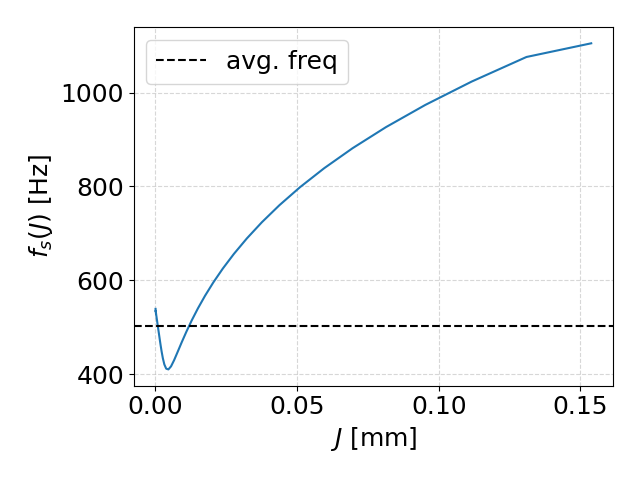

In [14]:
plt.figure()
plt.plot(
    equi.equilibrium_info['action']*1e3,
    equi.equilibrium_info['sync_freq'])
plt.axhline(
    equi.equilibrium_info['avg_sync_freq'], label='avg. freq',
    color='k', ls='--')
plt.xlabel(r'$J$ [mm]')
plt.ylabel(r'$f_s(J)$ [Hz]')
plt.legend()
plt.tight_layout()
plt.show()

<IPython.core.display.Javascript object>


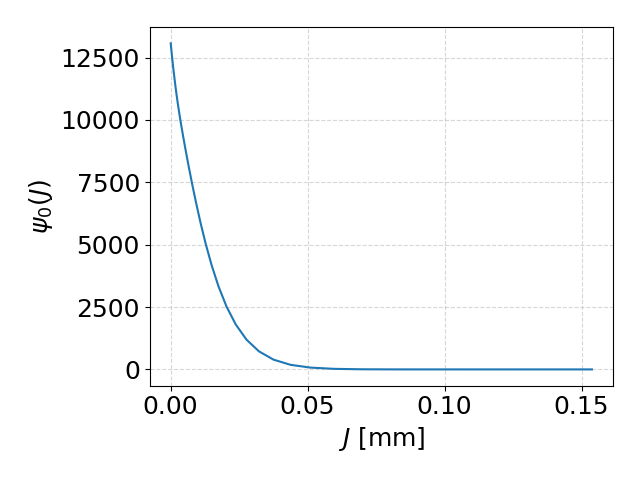

In [15]:
plt.figure()
plt.plot(
    equi.equilibrium_info['action']*1e3,
    equi.equilibrium_info['action_distribution'])
plt.xlabel(r'$J$ [mm]')
plt.ylabel(r'$\psi_0(J)$')
plt.tight_layout()
plt.show()

# Compute canonical transformation $z_{ij} = z(J_i, \phi_j)$
The results are stored in the instance attribute `equilibrium_info`, which is updated to include:
- 'canonical_zj': List of arrays with the new longitudinal positions $z_j$ 
  along each trajectory (constant action).
- 'canonical_deltaj': List of arrays with the corresponding canonical 
  momenta $\delta_j$ along each trajectory.


In [19]:
_ = equi.calc_canonical_transformation()  # z = z(J_i, phi_j)
zij = equi.equilibrium_info["canonical_zj"]
dij = equi.equilibrium_info["canonical_deltaj"]

<IPython.core.display.Javascript object>


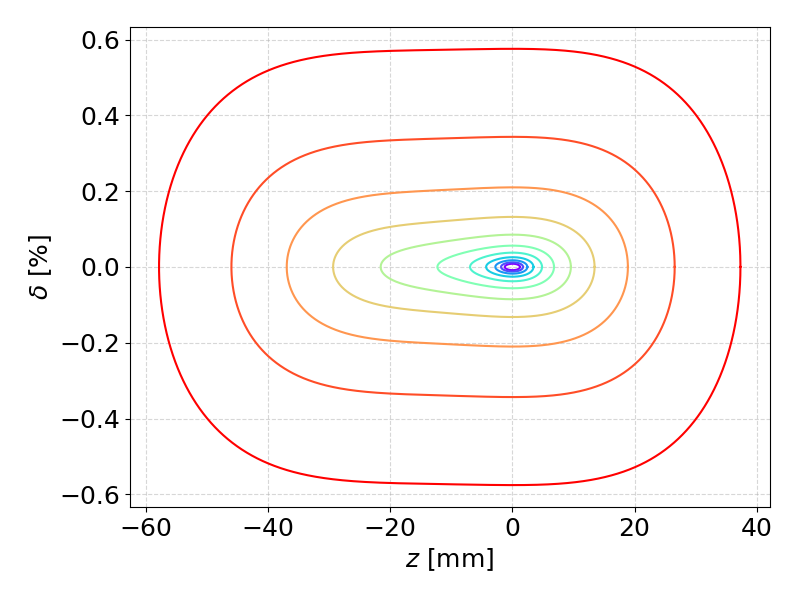

In [20]:
idcs = np.arange(0, 51, 5)

# Normalize the indices to map to the colormap range [0, 1]
norm = mcolors.Normalize(vmin=min(idcs), vmax=max(idcs))
cmap = cm.rainbow  # You can choose other colormaps like 'plasma', 'inferno', etc.

plt.figure(figsize=(8, 6))
for idx in idcs:
    z, d = np.array(zij[idx]) * 1e3, np.array(dij[idx]) * 1e2
    color = cmap(norm(idx))
    plt.plot(z, d, color=color, label=f"{equi.equilibrium_info['action'][idx]*1e4:.3f}")

plt.xlabel('$z$ [mm]')
plt.ylabel('$\delta$ [%]')
# plt.legend(title=r'Action $J \times 10$ [mm]', fontsize='xx-small')
plt.tight_layout()
plt.show()

# Examples of calculations with Lebedev equation

In [21]:
equi.calc_equilibrium_info(nrpts=51)  # compute action-dependent quantities

_ = equi.calc_canonical_transformation()  # z = z(J_i, phi_j)
zij = equi.equilibrium_info["canonical_zj"]

mmax = 2
cbmode = 1
ms = np.arange(1, mmax+1)
ps = np.array([-hcav.harm_rf, hcav.harm_rf])
w0 = equi.ring.rev_ang_freq
h = equi.ring.harm_num

hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)

x0 = [2*np.pi*10, 1/equi.ring.dampte]
coherent_freq, growth_rate = equi.solve_lebedev(x0, hmps, ms, ps, cbmode, method='lm', reduced=True)

In [22]:
print('Full Lebedev')
print('-'*30)
print(f'Coherent frequency: {coherent_freq:.2f} Hz')
print(f'Growth rate: {growth_rate:.6f} 1/ms')
print(f'Damping rate: {1/equi.ring.dampte:.4f} 1/s')

Full Lebedev
------------------------------
Coherent frequency: 396.07 Hz
Growth rate: 0.002695 1/ms
Damping rate: 77.5194 1/s


In [23]:
ms = np.sort(np.r_[-np.arange(1, mmax+1), np.arange(1, mmax+1)])
hmps = equi.calc_hmps(zij, cbmode, ms, ps, w0, h)
complex_freq, _ = equi.solve_lebedev_constant_frequency(hmps, ms, ps, cbmode, effsyncfreq='bunchlength')

In [24]:
print('Lebedev with Constant Frequency')
print('-'*30)

for freq in complex_freq:
    print(f'Coherent frequency: {freq.real/2/np.pi:.2f} Hz')
    print(f'Growth rate: {freq.imag :.6f} 1/s')
    print(f'Damping rate: {1/equi.ring.dampte:.4f} 1/s')
    print()

Lebedev with Constant Frequency
------------------------------
Coherent frequency: -1124.04 Hz
Growth rate: 0.000929 1/s
Damping rate: 77.5194 1/s

Coherent frequency: -1104.33 Hz
Growth rate: -0.000066 1/s
Damping rate: 77.5194 1/s

Coherent frequency: -468.85 Hz
Growth rate: -0.006842 1/s
Damping rate: 77.5194 1/s

Coherent frequency: -560.48 Hz
Growth rate: 0.000042 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 469.12 Hz
Growth rate: 0.006810 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 560.48 Hz
Growth rate: -0.000042 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 1123.95 Hz
Growth rate: -0.000919 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 1104.34 Hz
Growth rate: 0.000066 1/s
Damping rate: 77.5194 1/s



In [25]:
z0, sigmaz = equi.calc_moments(equi.zgrid, equi.distributions)
sigmaz = sigmaz[0]
#         sync_freq = (0.8039/2) * equi.ring.espread * equi.ring.mom_comp * c
sync_freq = equi.ring.espread * equi.ring.mom_comp * c
sync_freq /= sigmaz * 2 * np.pi

equi.ring.sync_tune = sync_freq / equi.ring.rev_freq
equi.ring.bunlen = sigmaz

# Calculate Vlasov's equation eigen-frequencies:
wrf = equi.ring.rf_ang_freq
complex_freq_lmci, *_ = equi.calc_mode_coupling(
    w=[-10 * wrf, +10 * wrf],
    cbmode=cbmode,
    max_azi=mmax,
    max_rad=1,
    use_fokker=False,
    delete_m0=True,
    delete_m0k0=True,
    reduced=True,
)

In [26]:
print('Gaussian LMCI')
print('-'*30)

for freq in complex_freq_lmci:
    print(f'Coherent frequency: {freq.real/2/np.pi:.2f} Hz')
    print(f'Growth rate: {freq.imag :.6f} 1/s')
    print(f'Damping rate: {1/equi.ring.dampte:.4f} 1/s')
    print()

Gaussian LMCI
------------------------------
Coherent frequency: 458.82 Hz
Growth rate: 107.727092 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 554.07 Hz
Growth rate: 0.243710 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 1124.95 Hz
Growth rate: 2.493975 1/s
Damping rate: 77.5194 1/s

Coherent frequency: 1108.34 Hz
Growth rate: 0.000858 1/s
Damping rate: 77.5194 1/s



# Change harmonic voltage and compute coherent complex frequencies for coupled-bunch mode 1

In [27]:
voltages = np.linspace(0.3, 1.0, 10) * fp_voltage
ad_rates, cf_rates, mc_rates, ich_freq, min_freq, max_freq = scan_hc_voltage(voltages, equi, cbmode=1, mmax=2)

HC voltage (kV)  HC detune (kHz)
         239.69          190.48
         301.83          151.16
         363.97          125.24
         426.12          106.86
         488.26           93.11
         550.40           82.41
         612.54           73.78
         674.68           66.55
         736.82           60.08
         798.97           53.19


<IPython.core.display.Javascript object>


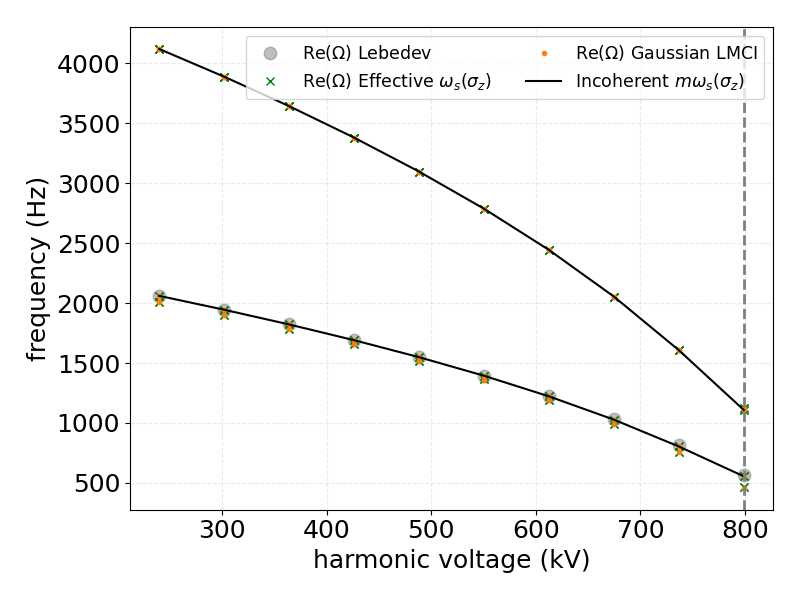

In [28]:
plot_scan_hc_voltage(
    voltages, fp_voltage,
    ad_rates, cf_rates, mc_rates, ich_freq)

<IPython.core.display.Javascript object>


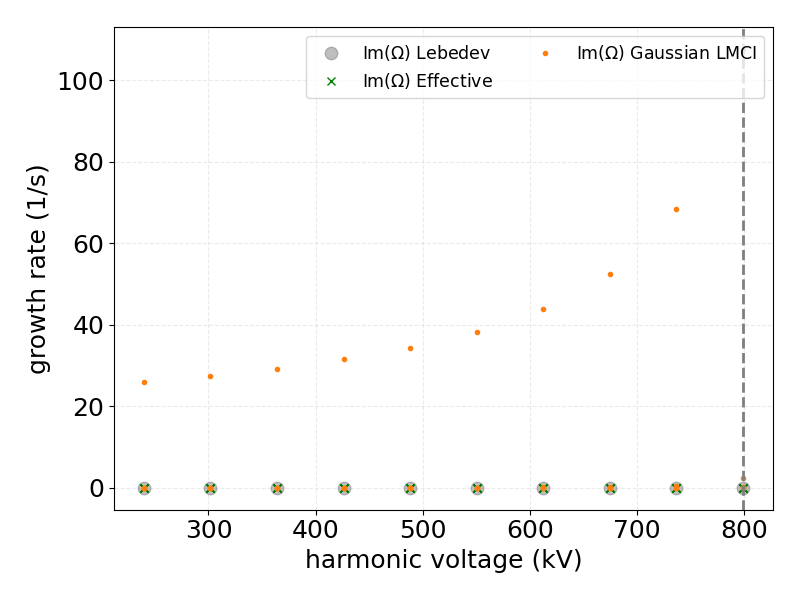

In [29]:
plot_scan_hc_voltage_growth(
    voltages, fp_voltage,
    ad_rates, cf_rates, mc_rates, ich_freq)

# Search for threshold current for coupled-bunch mode 1

In [30]:
thre_lebe = []
thre_effe = []
thre_lmci = []

voltages = np.linspace(2000, 3000, 6) * 1e3

curr0_lebe = 550
curr0_effe = 550
curr0_lmci = 550

nr_pts = 20
mmax = 2
curr_max = 800
cbmode = 1
tol = 0.5

Rs0 = mcav.shunt_impedance
mcav.shunt_impedance = 0

for volt in voltages:
    print(f"RF Voltage {volt/1e3:.2f} kV \n")
    ring.gap_voltage = volt
    mcav.ref_amp = ring.gap_voltage
    mcav.ref_phase = ring.sync_phase

    print("Gaussian LMCI")
    print("="*20)
    threshold_lmci = find_threshold_bisect(
        method='lmci', ring=ring, cav_list=[mcav, hcav],
        current_min=curr0_lmci, current_max=curr_max,
        cbmode=cbmode, mmax=mmax, tol=tol
    )
    thre_lmci.append(threshold_lmci)
    if threshold_lmci is not None:
        curr0_lmci = threshold_lmci

    print("\nLebedev")
    print("="*20)
    curr0_lebe = curr0_lmci * 1.025
    threshold_lebedev = find_threshold_bisect(
        method='lebedev', ring=ring, cav_list=[mcav, hcav],
        current_min=curr0_lebe, current_max=curr_max,
        cbmode=cbmode, mmax=mmax, tol=tol
    )
    thre_lebe.append(threshold_lebedev)
    if threshold_lebedev is not None:
        curr0_lebe = threshold_lebedev

    print("\nEffective Frequency")
    print("="*20)
    curr0_effe = curr0_lebe * 0.99
    threshold_eff = find_threshold_bisect(
        method='effective', ring=ring, cav_list=[mcav, hcav],
        current_min=curr0_effe, current_max=curr_max,
        cbmode=cbmode, mmax=mmax, tol=tol
    )
    thre_effe.append(threshold_eff)
    if threshold_eff is not None:
        curr0_eff = threshold_eff

thre_lebe = np.array(thre_lebe)
thre_effe = np.array(thre_effe)
thre_lmci = np.array(thre_lmci)

mcav.shunt_impedance = Rs0

RF Voltage 2000.00 kV 

Gaussian LMCI
HC voltage (kV)  HC detune (kHz)
Current: 675.00 mA
Growth rate 2122.8572, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 612.50 mA
Growth rate 1388.0808, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 581.25 mA
Growth rate 851.0070, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 565.62 mA
Growth rate 380.1968, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 557.81 mA
Growth rate 0.1748, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 561.72 mA
Growth rate 43.3678, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 563.67 mA
Growth rate 270.3737, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 562.70 mA
Growth rate 193.5516, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 562.21 mA
Growth rate 140.2266, Damping rate 77.52

Lebedev
HC voltage (kV)  HC detune (kHz)
Current: 688.13 mA
Growth rate 1939.8558, Damping rate 77.52
HC voltage (kV)  HC det

Growth rate 112.4653, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 684.60 mA
Growth rate 0.8488, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 684.91 mA
Growth rate 48.8643, Damping rate 77.52

Lebedev
HC voltage (kV)  HC detune (kHz)
Current: 751.17 mA
Growth rate 1114.5786, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 726.75 mA
Growth rate 697.8195, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 714.55 mA
Growth rate 349.1294, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 708.44 mA
Growth rate 0.2820, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 711.49 mA
Growth rate 179.7919, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 709.97 mA
Growth rate 0.6057, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 710.73 mA
Growth rate 100.0034, Damping rate 77.52
HC voltage (kV)  HC detune (kHz)
Current: 710.35 mA
Growth rate 1.9195, Damping rate 77.52

Effective Frequency
HC volt

<IPython.core.display.Javascript object>


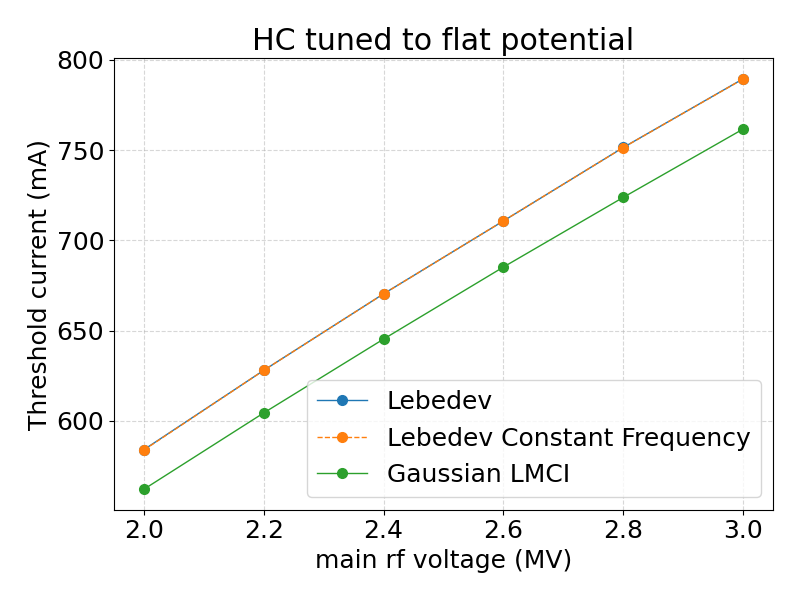

In [32]:
plt.figure(figsize=(8, 6))

plt.plot(voltages/1e6, thre_lebe, '-o', lw=1, ms=7, label=r'Lebedev')
plt.plot(voltages/1e6, thre_effe, '--o', lw=1, ms=7, label=r'Lebedev Constant Frequency')
plt.plot(voltages/1e6, thre_lmci, '-o', lw=1, ms=7, label=r'Gaussian LMCI')
plt.legend()

plt.xlabel("main rf voltage (MV)")
plt.ylabel("Threshold current (mA)")
plt.title("HC tuned to flat potential")
plt.tight_layout()
plt.show()